# 08 — Model Evaluation

**Goal:** For each model, collect predictions across all leave-one-cycle-out folds, compute
accuracy and confusion matrices separately for indoor and outdoor, and save result plots/tables
to `results/`.

Uses `sklearn.metrics.ConfusionMatrixDisplay` — sklearn's own plotting module, actively
maintained (avoiding the unmaintained `scikit-plot` package, which currently breaks on
modern scipy/numpy due to a removed `scipy.interp` import).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

PREPROCESSED_DIR = Path("../data/preprocessed")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

oof_df = pd.read_csv(PREPROCESSED_DIR / "oof_predictions.csv")
CLASS_ORDER = ["Urgent", "Soon", "Not_Urgent"]

oof_df.head()

,condition,model,test_cycle,true_label,predicted_label
0,indoor,logistic_regression,indoor_cycle01,Soon,Urgent
1,indoor,logistic_regression,indoor_cycle01,Urgent,Urgent
2,indoor,logistic_regression,indoor_cycle01,Urgent,Urgent
3,indoor,logistic_regression,indoor_cycle01,Urgent,Urgent
4,indoor,logistic_regression,indoor_cycle01,Urgent,Urgent


## Accuracy per model, per condition

Built group-by-group rather than via a single `groupby().apply()`, so a model/condition combination with zero collected predictions (e.g., every fold for that model was skipped in notebook 07 due to a single-class training fold) is reported as `NaN` rather than crashing the whole computation.

In [2]:
accuracy_rows = []
for (condition, model_name), group in oof_df.groupby(["condition", "model"]):
    if len(group) == 0:
        acc = float("nan")
    else:
        acc = accuracy_score(group["true_label"], group["predicted_label"])
    accuracy_rows.append({"condition": condition, "model": model_name, "accuracy": acc, "n_predictions": len(group)})

accuracy_table = pd.DataFrame(accuracy_rows).sort_values(["condition", "accuracy"], ascending=[True, False])

if accuracy_table["accuracy"].isna().any():
    print("Note: some model/condition combos have no predictions (likely skipped folds — see notebook 07 output).")
    print("This is expected with very small/imbalanced datasets; re-check once real data is in.\n")

accuracy_table

,condition,model,accuracy,n_predictions
0,indoor,decision_tree,0.96,50
2,indoor,random_forest,0.96,50
1,indoor,logistic_regression,0.94,50


## Confusion matrices — one grid per condition, all three models

Using `ConfusionMatrixDisplay` directly on precomputed matrices, sklearn's native plotting.

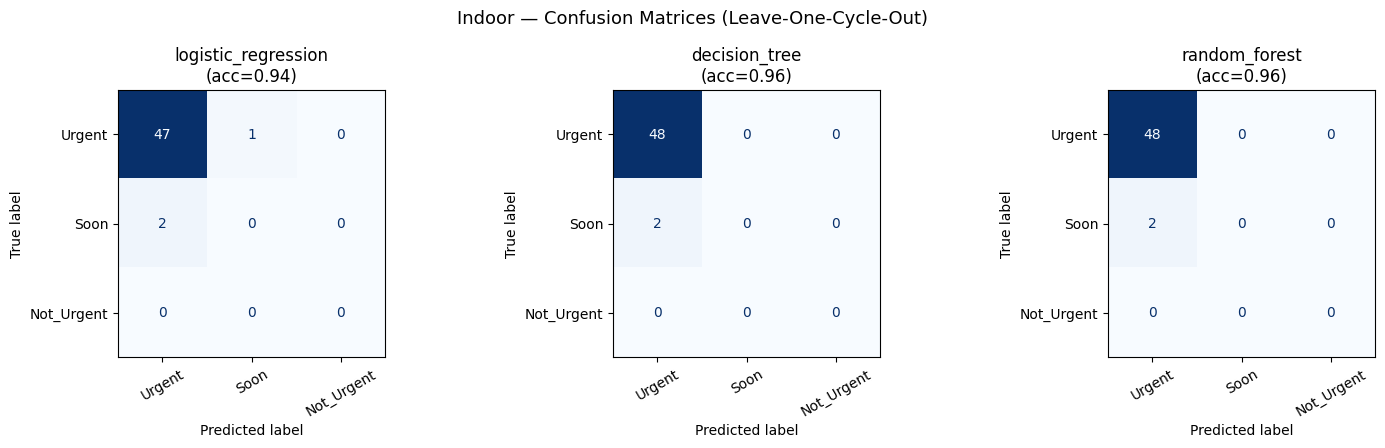

In [3]:
def plot_confusion_grid(oof_df, condition, class_order=CLASS_ORDER):
    models = oof_df["model"].unique()
    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.5))
    if len(models) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, models):
        subset = oof_df[(oof_df["condition"] == condition) & (oof_df["model"] == model_name)]
        if len(subset) == 0:
            ax.text(0.5, 0.5, "No predictions\n(fold(s) skipped —\nsee notebook 07)",
                     ha="center", va="center", fontsize=9, transform=ax.transAxes)
            ax.set_title(f"{model_name}\n(no data)")
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        cm = confusion_matrix(subset["true_label"], subset["predicted_label"], labels=class_order)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
        disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=30)
        acc = accuracy_score(subset["true_label"], subset["predicted_label"])
        ax.set_title(f"{model_name}\n(acc={acc:.2f})")

    fig.suptitle(f"{condition.capitalize()} — Confusion Matrices (Leave-One-Cycle-Out)", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"08_confusion_matrices_{condition}.png", dpi=130)
    plt.show()

plot_confusion_grid(oof_df, "indoor")

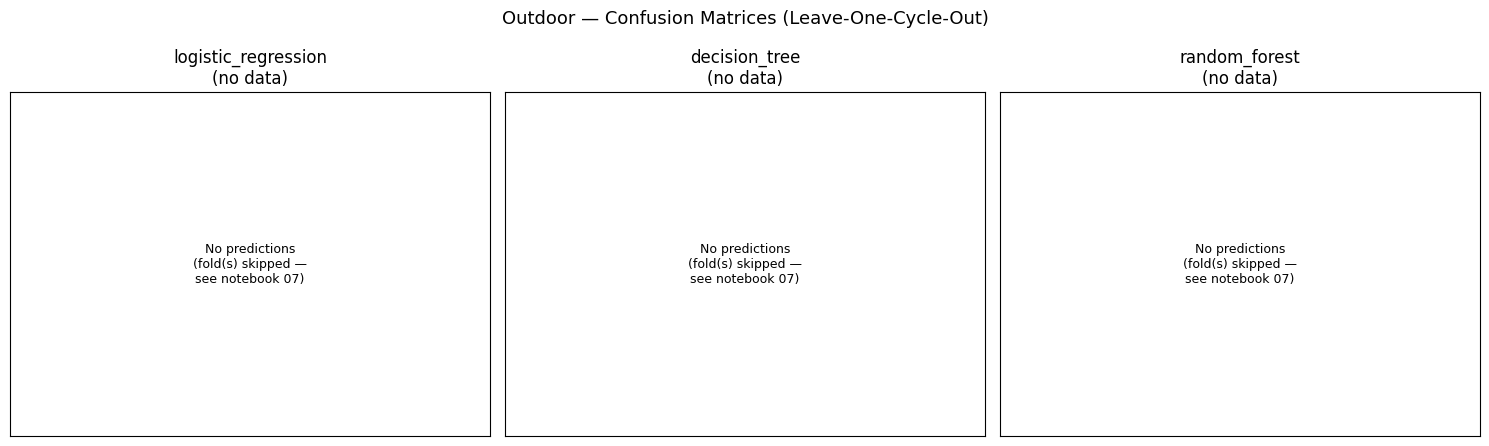

In [4]:
plot_confusion_grid(oof_df, "outdoor")

## Full classification report per model/condition

Precision, recall, F1 per class — more informative than accuracy alone, especially with small/imbalanced classes.

In [5]:
for condition in ["indoor", "outdoor"]:
    print(f"\n{'='*60}\n{condition.upper()}\n{'='*60}")
    for model_name in oof_df["model"].unique():
        subset = oof_df[(oof_df["condition"] == condition) & (oof_df["model"] == model_name)]
        print(f"\n--- {model_name} ---")
        if len(subset) == 0:
            print("(no predictions — every fold was skipped, see notebook 07 output)")
            continue
        print(classification_report(
            subset["true_label"], subset["predicted_label"],
            labels=CLASS_ORDER, zero_division=0,
        ))


INDOOR

--- logistic_regression ---
              precision    recall  f1-score   support

      Urgent       0.96      0.98      0.97        48
        Soon       0.00      0.00      0.00         2
  Not_Urgent       0.00      0.00      0.00         0

    accuracy                           0.94        50
   macro avg       0.32      0.33      0.32        50
weighted avg       0.92      0.94      0.93        50


--- decision_tree ---
              precision    recall  f1-score   support

      Urgent       0.96      1.00      0.98        48
        Soon       0.00      0.00      0.00         2
  Not_Urgent       0.00      0.00      0.00         0

    accuracy                           0.96        50
   macro avg       0.32      0.33      0.33        50
weighted avg       0.92      0.96      0.94        50


--- random_forest ---
              precision    recall  f1-score   support

      Urgent       0.96      1.00      0.98        48
        Soon       0.00      0.00      0.00   

## Save accuracy table

In [6]:
accuracy_table.to_csv(PREPROCESSED_DIR / "model_accuracy_table.csv", index=False)
print("Saved model_accuracy_table.csv")
accuracy_table

Saved model_accuracy_table.csv


,condition,model,accuracy,n_predictions
0,indoor,decision_tree,0.96,50
2,indoor,random_forest,0.96,50
1,indoor,logistic_regression,0.94,50


**Next step:** `09_model_comparison_and_selection.ipynb` — compare all three models side-by-side and formally document the deployment decision.